In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
Data = pd.read_csv("sales_data_with_discounts.csv")
Data.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [8]:
num_cols = Data.select_dtypes(include='number').columns.tolist()
cat_cols = Data.select_dtypes(exclude='number').columns.tolist()

In [11]:
num_cols

['Volume',
 'Avg Price',
 'Total Sales Value',
 'Discount Rate (%)',
 'Discount Amount',
 'Net Sales Value']

In [12]:
cat_cols

['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']

In [15]:
for col in num_cols:
    mean = Data[col].mean()
    median = Data[col].median()
    mode = Data[col].mode()[0]
    std_dev = Data[col].std()
    
    print(f"\nColumn: {col}")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Standard Deviation: {std_dev}")


Column: Volume
Mean: 5.066666666666666
Median: 4.0
Mode: 3
Standard Deviation: 4.231602391213926

Column: Avg Price
Mean: 10453.433333333332
Median: 1450.0
Mode: 400
Standard Deviation: 18079.90483993645

Column: Total Sales Value
Mean: 33812.83555555555
Median: 5700.0
Mode: 24300
Standard Deviation: 50535.07417255328

Column: Discount Rate (%)
Mean: 15.155241895330914
Median: 16.57776564929597
Mode: 5.007822189204133
Standard Deviation: 4.220602153325511

Column: Discount Amount
Mean: 3346.499424342415
Median: 988.9337332382784
Mode: 69.17794228822787
Standard Deviation: 4509.9029633539985

Column: Net Sales Value
Mean: 30466.336131270138
Median: 4677.788059301853
Mode: 326.97480055470817
Standard Deviation: 46358.656624066934


## Data Visualization

In [17]:
## Histograms 

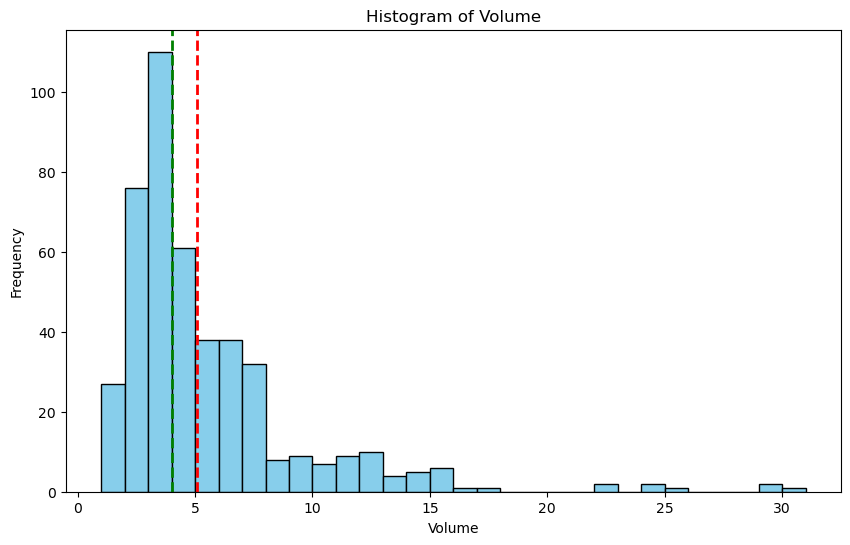

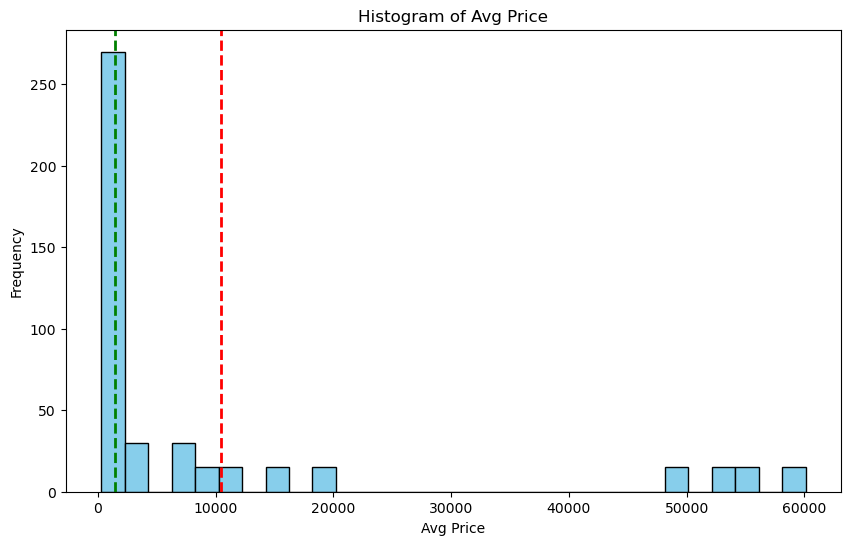

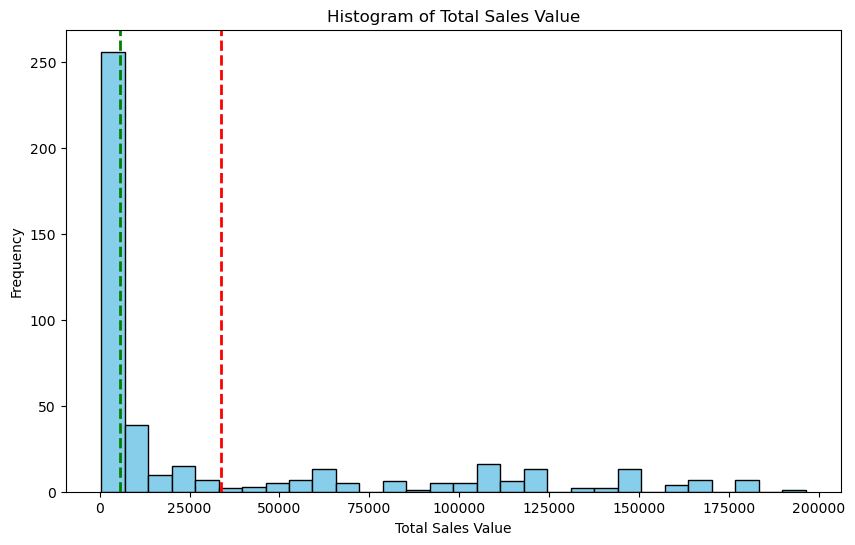

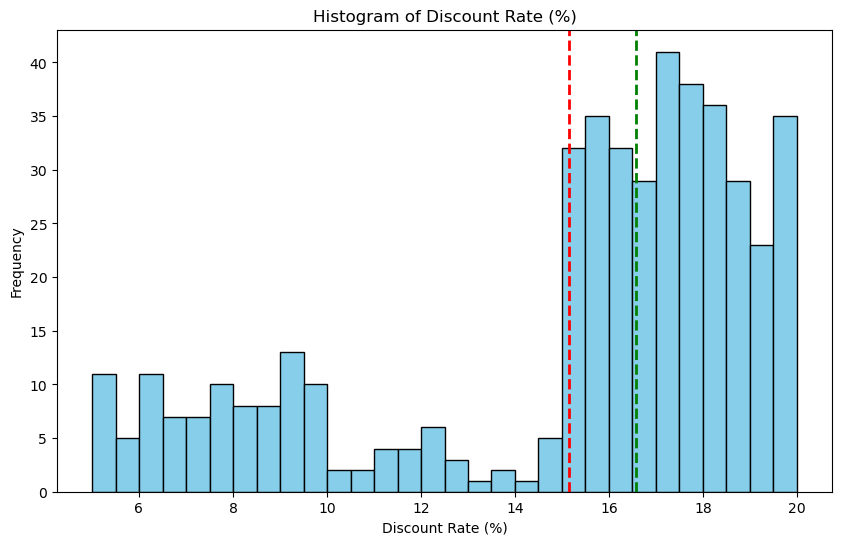

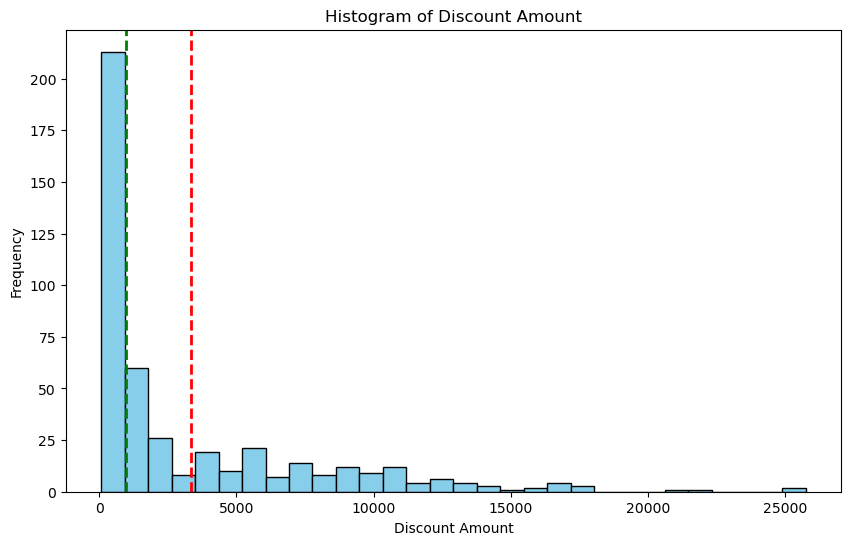

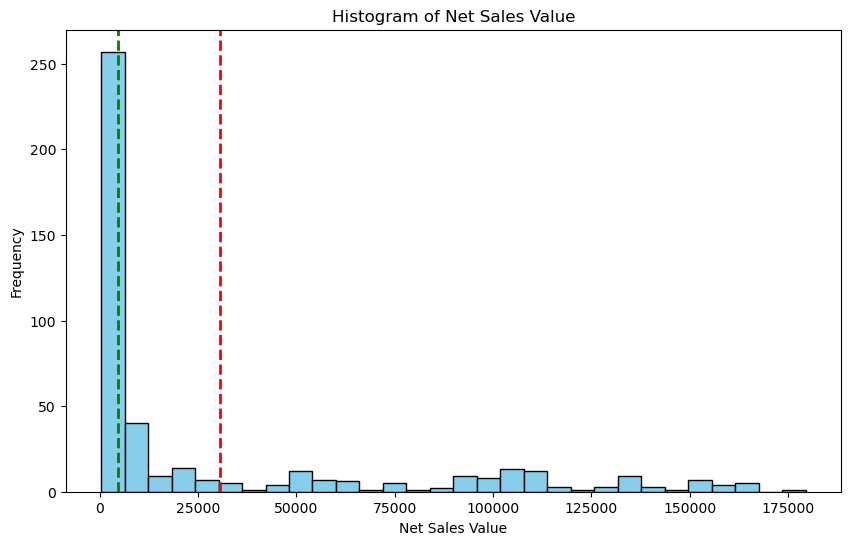

In [22]:
for col in num_cols:
    plt.figure(figsize=(10,6))
    plt.hist(Data[col], bins=30 , color='skyblue' , edgecolor='black')
    plt.axvline(Data[col].mean(), color='red', linestyle='dashed' ,linewidth=2, label='Mean')
    plt.axvline(Data[col].median(), color='green', linestyle='dashed' ,linewidth=2, label='Median')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [23]:
# Except for Discount Rate (%), all other numerical columns show right-skewed distributions with long tails toward higher values,
# indicating the presence of outliers. The majority of transactions occur at lower volumes, prices, and sales values, while a small
# number of transactions have significantly higher values, which increases the mean compared to the median. 
# The Discount Rate (%) appears to be fairly symmetric, with most values clustered around the average and relatively few extreme discount values

In [24]:
## BOX_PLOT

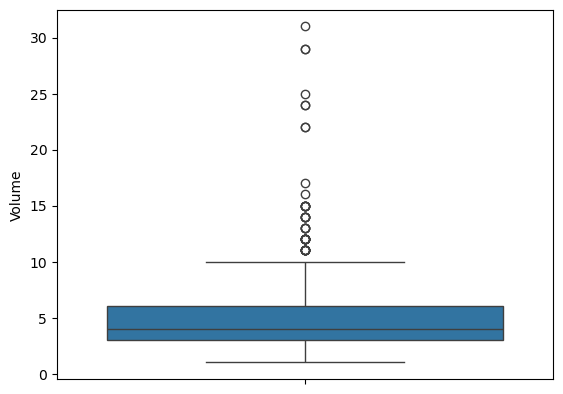

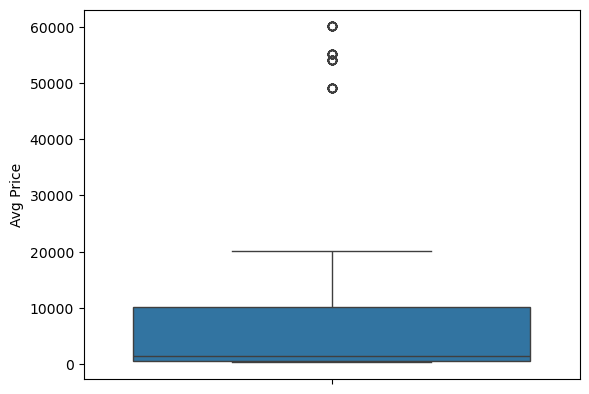

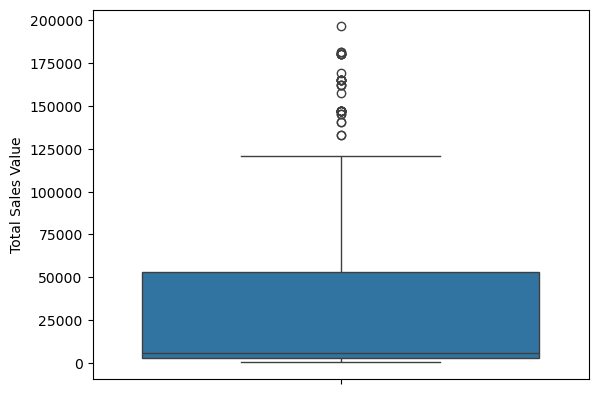

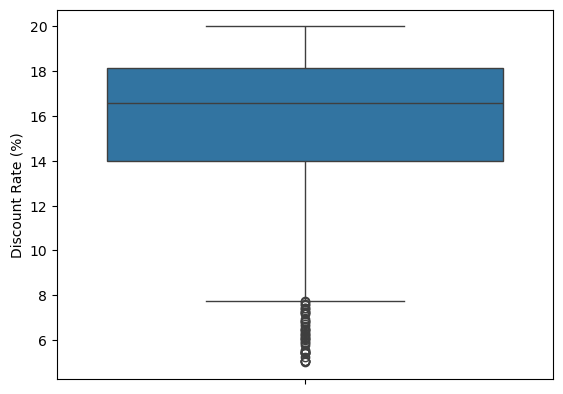

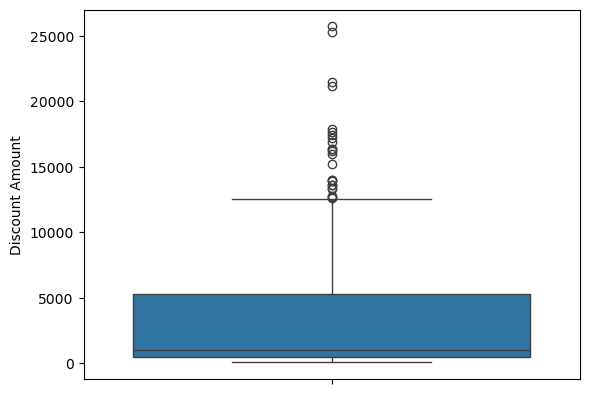

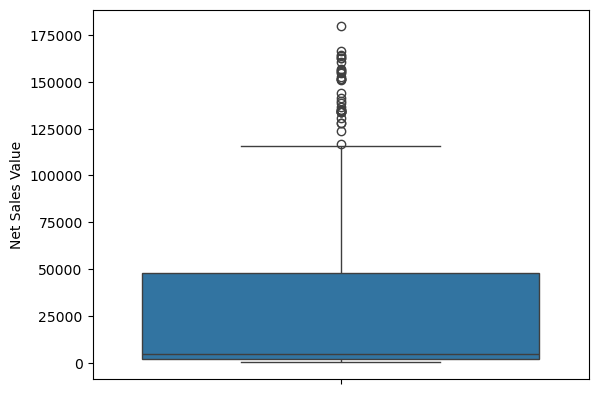

In [29]:
for col in num_cols:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [45]:
# identify outliers and the interquartile range.
def identify_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers
for col in num_cols:
    Q1, Q3,IQR, lower, upper,outliers = identify_outliers(Data[col])
    print(f"\nColumn Name: {col}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Number of Outliers: {len(outliers)}")


Column Name: Volume
IQR: 3.0
Lower Bound: -1.5
Upper Bound: 10.5
Number of Outliers: 44

Column Name: Avg Price
IQR: 9635.0
Lower Bound: -13987.5
Upper Bound: 24552.5
Number of Outliers: 60

Column Name: Total Sales Value
IQR: 50500.0
Lower Bound: -73050.0
Upper Bound: 128950.0
Number of Outliers: 36

Column Name: Discount Rate (%)
IQR: 4.149655934050962
Lower Bound: 7.740578642625298
Upper Bound: 24.339202378829146
Number of Outliers: 45

Column Name: Discount Amount
IQR: 4856.03612280112
Lower Bound: -6823.594880316146
Upper Bound: 12600.54961088833
Number of Outliers: 24

Column Name: Net Sales Value
IQR: 45645.70420627015
Lower Bound: -66266.347664084
Upper Bound: 116316.46916099661
Number of Outliers: 35


In [46]:
## Bar Chart Analysis for Categorical Column:

In [47]:
cat_cols

['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']

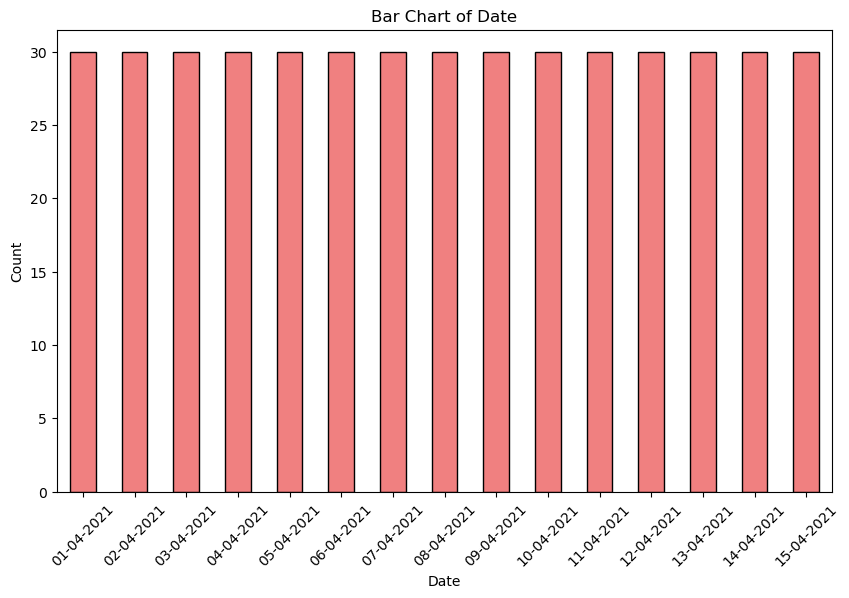

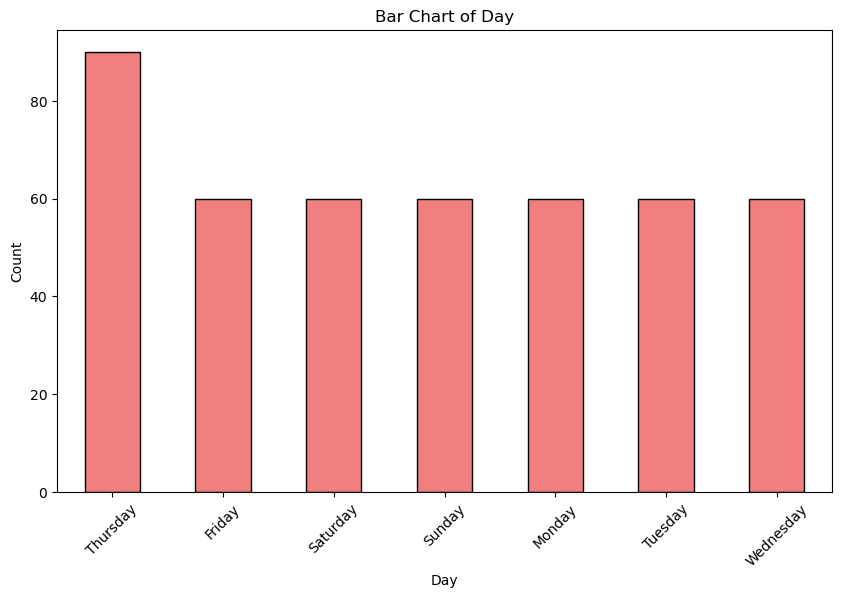

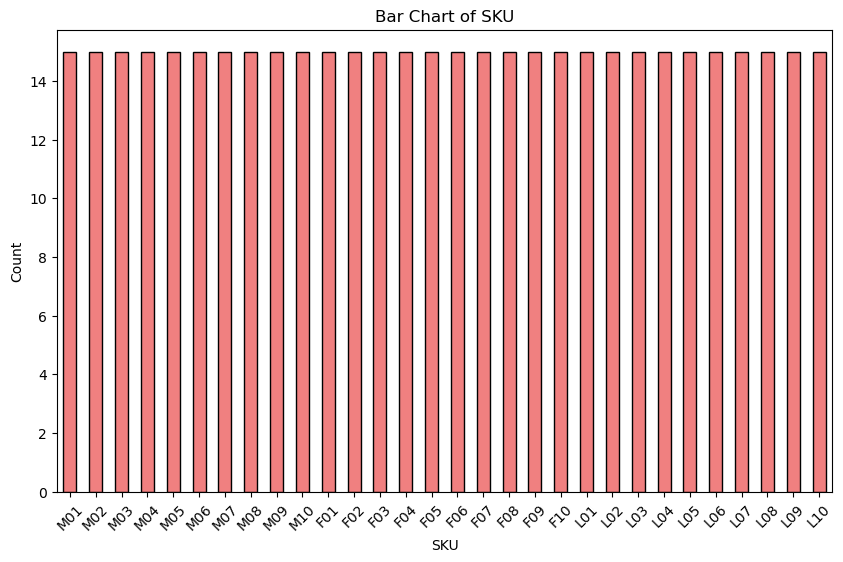

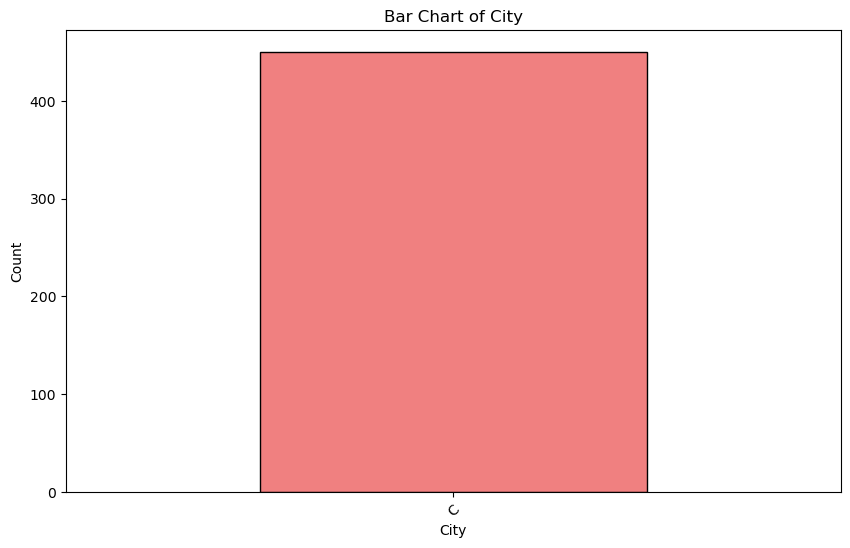

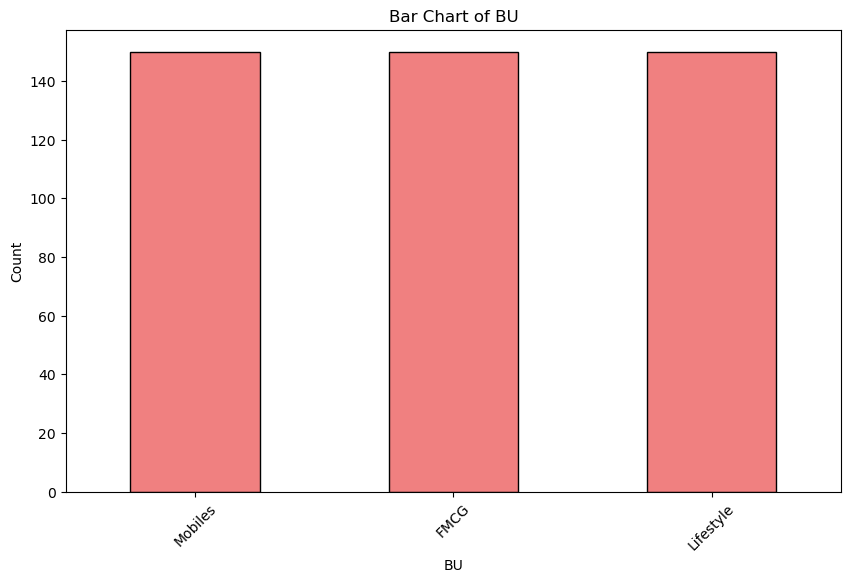

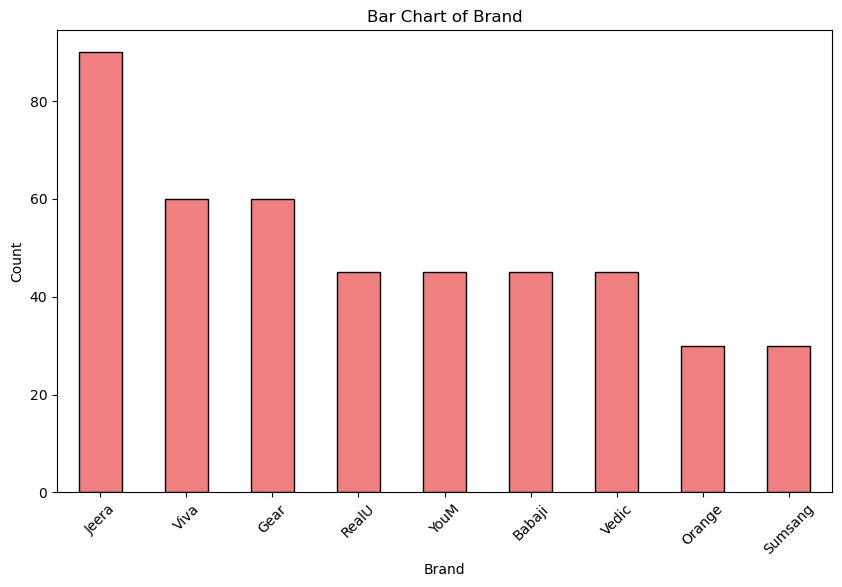

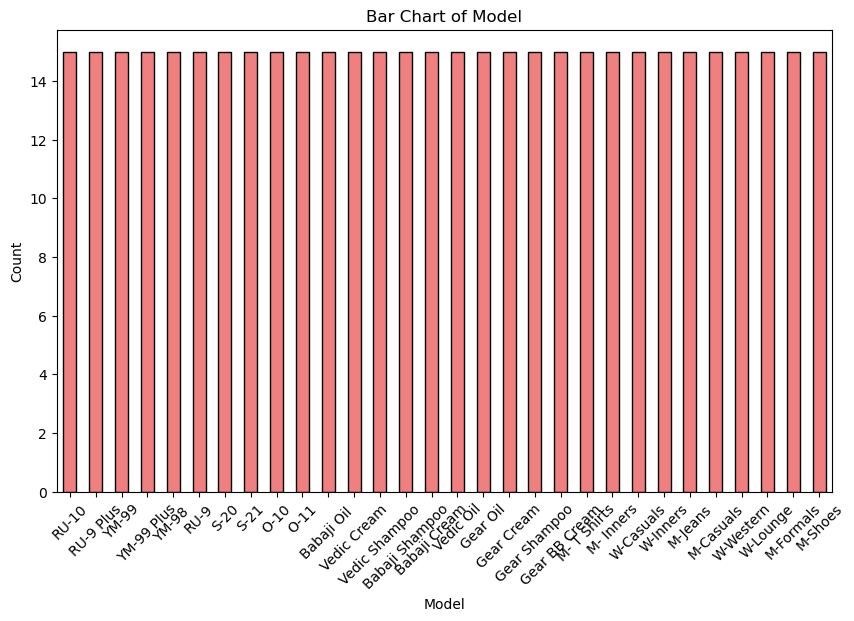

In [52]:
for col in cat_cols:
    plt.figure(figsize=(10,6))
    Data[col].value_counts().plot(kind='bar',color='lightcoral',edgecolor='black')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [59]:
## Date :The bar chart shows nearly equal frequencies across all dates. No particular date dominates the dataset.
## Day :Thursday has the highest count compared to other days.Other weekdays show relatively similar frequencies.
## SKU : Each SKU shows almost identical counts.No SKU significantly dominates.
## City : Only one city is present.The analysis is city-specific, and insights may not generalize to other locations.
## BU :All business units have similar frequencies.No BU overwhelmingly dominates the data.
## Brand :9 different brands across all business units.Balanced brand distribution suggests no single brand dependency
## Model :The dataset is well-balanced at the model level, meaning each product model is equally represented.

In [60]:
##OVERALL INSIGHTS:
# The dataset shows a well-balanced distribution across all categorical variables
# No category shows dominance or underrepresentation
# This suggests a diverse and evenly spread business operation
# The uniform distribution helps minimize risk associated with dependency on specific categories

In [61]:
# Conclusion :
# The data analysis shows that most values are small, but a few very large values exist, which increase the overall totals. 
# Box plots help identify these extreme values clearly. 
# The bar charts show that most categories (like day, brand, or product type) are fairly evenly distributed, with some categories appearing more 
# often than others. Overall, the dataset is balanced, but a small number of high-value records have a strong impact on the results.